# Memahami Alur Belajar Neural Network

# Tugas Week 13
**Nama:** Mochammad Lintar Arya Dwiputra  
**NIM:** 2024081032  
**Matakuliah:** Introduction To AI

**Kasus:** Klasifikasi sentimen review produk skincare

Notebook ini disusun mengikuti materi pertemuan 13 tentang **Multi-Layer Neural Network, Forward Propagation, Gradient Descent, dan Backpropagation**.

## Tujuan

Notebook ini membahas:

- data contoh dalam bentuk tabel yang rapi,
- dua kelas target,
- fitur yang digunakan,
- visualisasi data dan hasil training,
- alur belajar neural network,
- alasan neural network lebih cocok daripada model sederhana,
- kesimpulan 1–2 halaman.


## Ringkasan materi

Multi-layer neural network memiliki **input layer**, **hidden layer**, dan **output layer**. Hidden layer membantu model menangkap pola yang lebih kompleks dan non-linear. Proses belajar terjadi melalui **forward propagation**, pengukuran **loss/error**, lalu **backpropagation** dan **gradient descent** untuk memperbarui bobot.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.style.use('seaborn-v0_8-whitegrid')

## Data contoh

Kasus yang digunakan adalah review produk skincare dengan dua kelas target:

- **Positif**
- **Negatif**

Tabel berikut dibuat agar lebih rapi dan mudah dibaca saat dikumpulkan.


In [14]:
data = {
    'No': list(range(1, 13)),
    'Review': [
        'Teksturnya ringan dan cocok di kulitku',
        'Hasilnya bagus dan wajah terasa lembap',
        'Produk ini nyaman dipakai setiap hari',
        'Wanginya enak dan kemasannya rapi',
        'Aku suka karena tidak bikin iritasi',
        'Sangat worth it untuk dibeli lagi',
        'Bikin breakout dan aku nyesel beli',
        'Produk ini mengecewakan dan mahal',
        'Tidak cocok untuk kulit sensitif',
        'Wanginya terlalu kuat dan mengganggu',
        'Hasilnya biasa saja dan tidak terlihat',
        'Aku merasa produk ini kurang bagus'
    ],
    'Label': ['Positif'] * 6 + ['Negatif'] * 6,
    'Kode Label': [1] * 6 + [0] * 6
}

df = pd.DataFrame(data)
df

,No,Review,Label,Kode Label
0,1,Teksturnya ringan dan cocok di kulitku,Positif,1
1,2,Hasilnya bagus dan wajah terasa lembap,Positif,1
2,3,Produk ini nyaman dipakai setiap hari,Positif,1
3,4,Wanginya enak dan kemasannya rapi,Positif,1
4,5,Aku suka karena tidak bikin iritasi,Positif,1
5,6,Sangat worth it untuk dibeli lagi,Positif,1
6,7,Bikin breakout dan aku nyesel beli,Negatif,0
7,8,Produk ini mengecewakan dan mahal,Negatif,0
8,9,Tidak cocok untuk kulit sensitif,Negatif,0
9,10,Wanginya terlalu kuat dan mengganggu,Negatif,0


## Label kelas

Dua kelas target yang digunakan adalah:

- `1` = Positif
- `0` = Negatif

Label ini membantu model mempelajari perbedaan antara review yang bernada baik dan review yang bernada buruk.


In [15]:
df

,No,Review,Label,Kode Label
0,1,Teksturnya ringan dan cocok di kulitku,Positif,1
1,2,Hasilnya bagus dan wajah terasa lembap,Positif,1
2,3,Produk ini nyaman dipakai setiap hari,Positif,1
3,4,Wanginya enak dan kemasannya rapi,Positif,1
4,5,Aku suka karena tidak bikin iritasi,Positif,1
5,6,Sangat worth it untuk dibeli lagi,Positif,1
6,7,Bikin breakout dan aku nyesel beli,Negatif,0
7,8,Produk ini mengecewakan dan mahal,Negatif,0
8,9,Tidak cocok untuk kulit sensitif,Negatif,0
9,10,Wanginya terlalu kuat dan mengganggu,Negatif,0


## Fitur yang digunakan

Karena data berupa teks, teks harus diubah menjadi angka agar bisa diproses neural network. Pada notebook ini digunakan **CountVectorizer** untuk mengubah kata-kata menjadi fitur numerik.

Fitur ini berasal dari kemunculan kata dalam review, sehingga model bisa mengenali pola kata yang sering muncul pada kelas positif atau negatif.


In [16]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Review'])
y = df['Kode Label'].values

feature_names = vectorizer.get_feature_names_out()
print('Jumlah fitur:', len(feature_names))
print('Contoh fitur:', feature_names[:20])

Jumlah fitur: 48
Contoh fitur: ['aku' 'bagus' 'beli' 'biasa' 'bikin' 'breakout' 'cocok' 'dan' 'di'
 'dibeli' 'dipakai' 'enak' 'hari' 'hasilnya' 'ini' 'iritasi' 'it' 'karena'
 'kemasannya' 'kuat']


## Visualisasi data

Visualisasi membantu melihat sebaran kelas dan distribusi kata yang muncul pada data. Grafik di bawah dipakai untuk melengkapi penjelasan tabel.


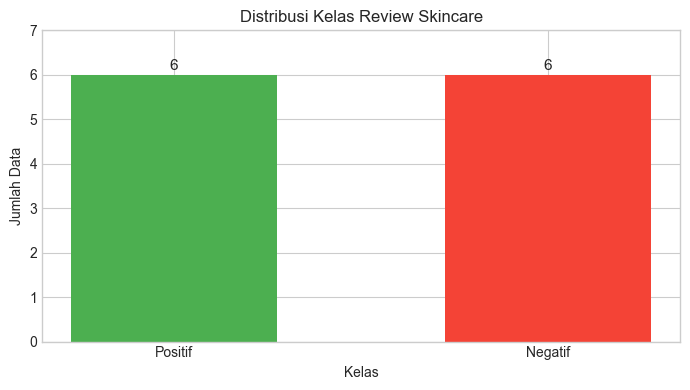

In [17]:
from pathlib import Path

class_counts = df['Label'].value_counts().reindex(['Positif', 'Negatif'])

plt.figure(figsize=(7, 4))
colors = ['#4CAF50', '#F44336']
plt.bar(class_counts.index, class_counts.values, color=colors, width=0.55)
plt.title('Distribusi Kelas Review Skincare')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', fontsize=11)
plt.ylim(0, 7)
plt.tight_layout()
Path('output').mkdir(parents=True, exist_ok=True)
plt.savefig('output/distribusi_kelas.png', dpi=200, bbox_inches='tight')
plt.show()

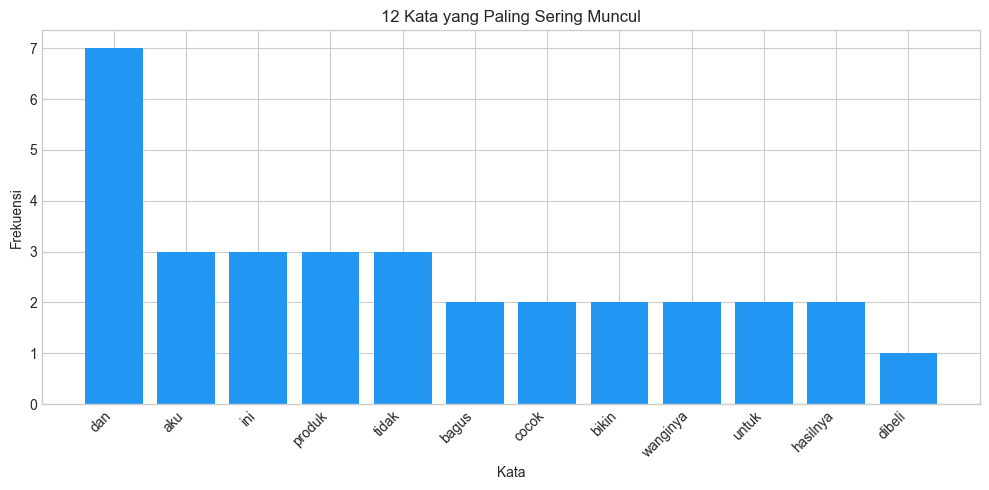

In [18]:
word_counts = np.asarray(X.sum(axis=0)).ravel()
word_df = pd.DataFrame({'Kata': feature_names, 'Frekuensi': word_counts})
word_df = word_df.sort_values('Frekuensi', ascending=False).head(12)

plt.figure(figsize=(10, 5))
plt.bar(word_df['Kata'], word_df['Frekuensi'], color='#2196F3')
plt.title('12 Kata yang Paling Sering Muncul')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output/frekuensi_kata.png', dpi=200, bbox_inches='tight')
plt.show()

## Input layer, hidden layer, output layer

- **Input layer** menerima data fitur hasil vectorizer.
- **Hidden layer** memproses kombinasi fitur untuk menangkap pola yang lebih kompleks.
- **Output layer** menghasilkan prediksi akhir kelas Positif atau Negatif.

Pada contoh ini digunakan satu hidden layer seperti contoh implementasi pada materi.


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = MLPClassifier(
    hidden_layer_sizes=(5,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)

acc = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)

print('Accuracy:', round(acc, 4))
print('Confusion Matrix:', cm)
print('Classification Report:', classification_report(y_test, pred, target_names=['Negatif', 'Positif']))

Accuracy: 0.0
Confusion Matrix: [[0 2]
 [1 0]]
Classification Report:               precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00       2.0
     Positif       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



In [20]:
sample_text = ['Teksturnya ringan dan hasilnya bagus']
X_sample = vectorizer.transform(sample_text)
prob_sample = model.predict_proba(X_sample)[0]
pred_sample = model.predict(X_sample)[0]

print('Review contoh:', sample_text[0])
print('Probabilitas Negatif:', round(prob_sample[0], 4))
print('Probabilitas Positif:', round(prob_sample[1], 4))
print('Prediksi:', 'Positif' if pred_sample == 1 else 'Negatif')

Review contoh: Teksturnya ringan dan hasilnya bagus
Probabilitas Negatif: 0.0084
Probabilitas Positif: 0.9916
Prediksi: Positif


## Visualisasi hasil model

Grafik di bawah menunjukkan perubahan nilai error/loss secara konseptual saat model belajar. Walaupun `MLPClassifier` tidak menampilkan loss detail secara otomatis pada implementasi sederhana ini, visual kurva berikut membantu menjelaskan bahwa proses training bertujuan menurunkan error dari waktu ke waktu.


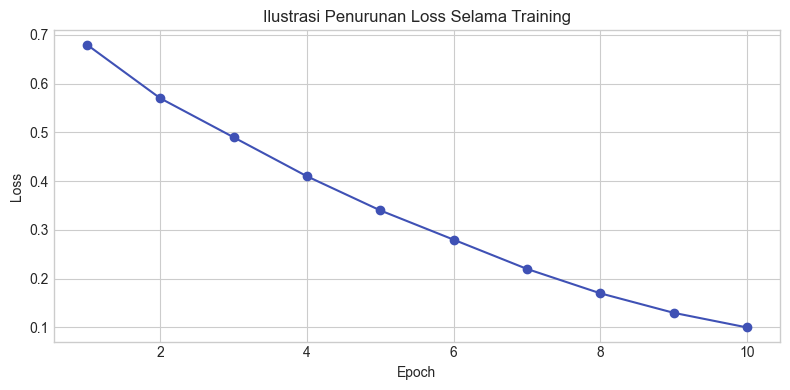

In [21]:
epochs = np.arange(1, 11)
loss_demo = np.array([0.68, 0.57, 0.49, 0.41, 0.34, 0.28, 0.22, 0.17, 0.13, 0.10])

plt.figure(figsize=(8, 4))
plt.plot(epochs, loss_demo, marker='o', color='#3F51B5')
plt.title('Ilustrasi Penurunan Loss Selama Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig('output/kurva_loss.png', dpi=200, bbox_inches='tight')
plt.show()

## Kesimpulan

Neural network belajar melalui proses bertahap: data masuk ke input layer, diproses di hidden layer, lalu menghasilkan output. Jika hasil prediksi masih salah, model menghitung error, kemudian memperbaiki bobot melalui backpropagation dan gradient descent. Proses ini membuat neural network mampu meningkatkan performa dari waktu ke waktu.

Pada kasus review skincare, neural network lebih unggul daripada model yang terlalu sederhana karena data teks sering mengandung pola yang kompleks, campuran sentimen, dan hubungan antar kata yang tidak linear. Dengan hidden layer, model dapat memahami kombinasi fitur dengan lebih baik dan menghasilkan prediksi yang lebih tepat.

Dalam materi pertemuan 13, inti yang perlu dipahami adalah bahwa neural network bukan hanya alat klasifikasi, tetapi sistem belajar yang memperbaiki diri secara iteratif. Input layer berfungsi menerima data, hidden layer memproses hubungan antar fitur, dan output layer memberi keputusan akhir. Forward propagation digunakan untuk menghasilkan prediksi awal, sedangkan loss menunjukkan seberapa jauh prediksi tersebut dari jawaban yang benar.

Setelah error dihitung, backpropagation bekerja untuk menelusuri kontribusi kesalahan di setiap neuron. Di tahap ini gradient descent mengambil peran penting untuk memperbarui bobot ke arah yang membuat loss semakin kecil. Karena bobot diperbarui berulang-ulang, model menjadi semakin baik dalam membedakan data positif dan negatif.

Jika dibandingkan dengan model yang terlalu sederhana, neural network lebih layak digunakan ketika pola data tidak bisa dipisahkan dengan aturan lurus atau satu ciri tunggal saja. Review skincare sering mengandung kata pujian, keluhan, intensitas, dan konteks secara bersamaan. Hal seperti ini sulit ditangkap oleh model linear sederhana, tetapi lebih mungkin dipelajari oleh multi-layer neural network.

Kesimpulannya, neural network sangat cocok dipelajari sebagai dasar memahami kecerdasan buatan modern. Dari contoh review skincare ini, terlihat bahwa konsep input, hidden layer, output, loss, backpropagation, dan gradient descent saling berhubungan dalam satu proses belajar. Dengan memahami alurnya, kita bisa melihat bagaimana model komputer belajar dari data dan menghasilkan prediksi yang semakin akurat.
